<a href="https://colab.research.google.com/github/hirnia/Etc/blob/main/Geom_AI_Tutorial_Wk7a.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Geometric AI: E(3)-Equivariant Convolution
**STAT 9100 — Companion Notebook (Modern `e3nn` API)**  
*Based on Tess E. Smidt's tutorial — the [`e3nn` convolution guide](https://docs.e3nn.org/en/stable/guide/convolution.html).*

---

This notebook accompanies the STAT 9100 lecture on Geometric Deep Learning. We implement the E(3)-equivariant graph convolution and empirically verify the symmetry guarantee — a clean statistical test that rotate-then-convolve equals convolve-then-rotate.

---

## Package Notes

`torch_scatter` and `torch_cluster` ship **separate wheels for each PyTorch × CUDA combination** — they are not on standard PyPI (and as a note from Megan, these wheels may take extra time, so please give yourself extra time). Install with:

```bash
# 1. Install PyTorch first (CPU-only example):
pip install torch

# 2. Check your torch version:
python -c "import torch; print(torch.__version__)"  # e.g. 2.2.0+cpu

# 3. Install scatter/cluster from the PyG index (adjust the URL for your version):
pip install torch-scatter torch-cluster \
    -f https://data.pyg.org/whl/torch-2.2.0+cpu.html

# 4. Install e3nn (>= 0.5.0 required for this API):
pip install "e3nn>=0.5.0" matplotlib
```


In [6]:
# Detect versions (just in case)
import torch
TORCH = torch.__version__.split('+')[0]
CUDA = "cpu" #If needed

print(f"Installing for PyTorch {TORCH} and {CUDA}...")

# 3. Use the specific PyG index to find the matching wheels
# Note: If 2.10.0 is brand new, the wheels might be in a 'stable' folder or under a slightly different path
!pip install torch-cluster -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-scatter -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html


Found existing installation: torch_cluster 1.6.3+pt22cpu
Uninstalling torch_cluster-1.6.3+pt22cpu:
  Successfully uninstalled torch_cluster-1.6.3+pt22cpu
Found existing installation: torch_scatter 2.1.2+pt22cpu
Uninstalling torch_scatter-2.1.2+pt22cpu:
  Successfully uninstalled torch_scatter-2.1.2+pt22cpu
Installing for PyTorch 2.10.0 and cpu...
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-cluster: filename=torch_cluster-1.6.3-cp312-cp312-linux_x86_64.whl size=818323 sha256=7ede74f92c3107ee26eb607bf63ed10e6d8b709a8a4e2c935928846ad9e7b13d
  Stored in directory: /root/.cache/pip/wheels/2e/8f/d0/13408a84825c9a587151a74727b4a6d47ec67e0d625b385ad7
Successfully built torch-cluster
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.3 MB/s eta 0:00:00
  

In [7]:
import torch
from torch_cluster import radius_graph
from torch_scatter import scatter
from e3nn import o3, nn
from e3nn.math import soft_one_hot_linspace
import matplotlib.pyplot as plt
import matplotlib as mpl

# Reproducibility
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

# Mizzou Gold palette
mpl.rcParams.update({
    "axes.prop_cycle": mpl.cycler(color=["#F1B82D", "#333333", "#888888"]),
    "figure.dpi": 110,
})

import e3nn
print(f"torch  {torch.__version__}")
print(f"e3nn   {e3nn.__version__}")

torch  2.10.0+cpu
e3nn   0.6.0


---
## 1 · The Language of `e3nn`: Irreducible Representations

The central object in `e3nn` is not a plain tensor — it is an **irreducible representation** (`Irreps`), which carries its own transformation law under rotation. Think of it as a typed tensor: the type tells the network *how* to rotate each chunk of the feature vector.

| `e3nn` notation | Physical meaning | Dim | Transforms like… |
|---|---|---|---|
| `0e` | even scalar ($L=0$) | 1 | unchanged |
| `1e` | even vector ($L=1$) | 3 | a 3D arrow |
| `2e` | even rank-2 tensor ($L=2$) | 5 | a quadrupole |

This typing is what makes the architecture *geometrically aware* — the network cannot accidentally mix a scalar with a vector because the types won't unify.

In [8]:
irreps_input  = o3.Irreps("10x0e + 10x1e")   # 10 scalars + 10 vectors in
irreps_output = o3.Irreps("20x0e + 10x1e")   # 20 scalars + 10 vectors out

print("Input  irreps:", irreps_input,  " → dim", irreps_input.dim)
print("Output irreps:", irreps_output, " → dim", irreps_output.dim)

Input  irreps: 10x0e+10x1e  → dim 40
Output irreps: 20x0e+10x1e  → dim 50


---
## 2 · The Graph: A Random Point Cloud

We use a random point cloud rather than a fixed molecule — generality is the point. Any set of 3D positions with a neighbor radius produces the same kind of graph.

Two quick sanity checks worth noting for a stats audience: the input features and the edge embeddings we build later should each have a **second moment ≈ 1** (component normalization). This is the `e3nn` analogue of standardizing your features before regression — it keeps gradients well-conditioned across the Clebsch-Gordan operations.

In [9]:
num_nodes  = 100
pos        = torch.randn(num_nodes, 3)   # N×3 positions in R^3
max_radius = 1.8

# Build edges to connect every pair of nodes within max_radius
edge_src, edge_dst = radius_graph(pos, max_radius,
                                   max_num_neighbors=num_nodes - 1)
edge_vec = pos[edge_dst] - pos[edge_src]  # relative displacement vectors

num_neighbors = len(edge_src) / num_nodes  # average degree  z

# Random input features drawn componentwise from N(0,1)
f_in = irreps_input.randn(num_nodes, -1)

print(f"Nodes: {num_nodes}  |  Edges: {len(edge_src)}  |  Avg degree z ≈ {num_neighbors:.1f}")
print(f"Feature 2nd moment (should ≈ 1.0): {f_in.pow(2).mean():.3f}")

Nodes: 100  |  Edges: 3586  |  Avg degree z ≈ 35.9
Feature 2nd moment (should ≈ 1.0): 1.000


---
## 3 · Building the Convolution

The E(3)-equivariant convolution formula from the lecture (compare to the plain MPNN message $m_v^{t+1} = \sum_{w} M_t(x_v, x_w, x_{vw})$):

$$f'_i = \frac{1}{\sqrt{z}} \sum_{j \in \partial(i)} f_j \;\otimes\!(h(\|x_{ij}\|))\; Y\!\left(\frac{x_{ij}}{\|x_{ij}\|}\right)$$

Four explicit steps:

### Step 3a · Spherical Harmonics $Y_{lm}(\hat{r})$ — the angular part

Spherical harmonics encode the **direction** of each edge. They are the angular analogue of a Fourier basis — orthonormal functions on $S^2$, indexed by degree $l$ and order $m$.

In [10]:
irreps_sh = o3.Irreps.spherical_harmonics(lmax=2)
print("SH irreps:", irreps_sh)

sh = o3.spherical_harmonics(
    irreps_sh, edge_vec,
    normalize=True,            # divides each edge_vec by |edge_vec| first
    normalization='component'
)
print(f"SH 2nd moment (should ≈ 1.0): {sh.pow(2).mean():.3f}")

SH irreps: 1x0e+1x1o+1x2e
SH 2nd moment (should ≈ 1.0): 1.000


### Step 3b · Tensor Product $\otimes$ — the equivariant combine

The **Clebsch-Gordan tensor product** combines features while respecting their geometric types — the equivariant analogue of an elementwise multiply. Setting `shared_weights=False` means the radial MLP (next step) supplies per-edge weights, making the filter both direction- *and* distance-sensitive.

In [ ]:
tp = o3.FullyConnectedTensorProduct(
    irreps_input, irreps_sh, irreps_output,
    shared_weights=False
)
print(f"Tensor product needs {tp.weight_numel} weights per edge")
tp.visualize();

### Step 3c · Radial Basis + MLP $h(\|x_{ij}\|)$ — the distance part

We embed edge *distances* into a smooth finite-support basis — the `smooth_finite` functions are strictly zero beyond `max_radius`, ensuring the convolution is smooth at the cutoff boundary. An MLP then maps these embeddings to the tensor product weights.

This is the radial part $R(r)$ from the slides, now implemented explicitly as a learned function.

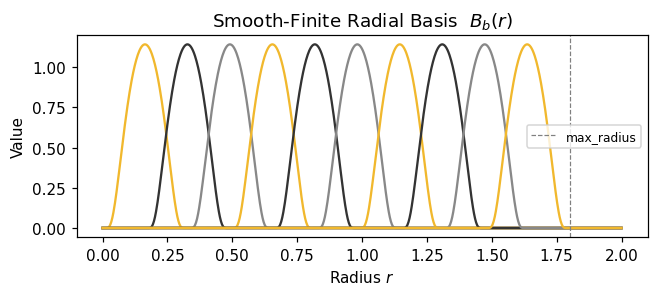

Weight shape: torch.Size([3586, 400])  (one weight vector per edge)
Weight mean ≈ -0.0188  (should ≈ 0)
Weight std  ≈ 0.7108  (should ≈ 1)


In [14]:
num_basis = 10
# Tensor Products Example: scalars (0e) and vectors (1o)
irreps_node_input = o3.Irreps("16x0e + 4x1o")
irreps_geometry     = o3.Irreps("1x0e + 1x1o")
irreps_node_output = o3.Irreps("16x0e + 4x1o")

# Create the Tensor Product object
tp = o3.FullyConnectedTensorProduct(
    irreps_node_input,
    irreps_geometry,
    irreps_node_output
)

# --- Visualize the basis ---
x_vis = torch.linspace(0.0, 2.0, 1000)
y_vis = soft_one_hot_linspace(x_vis, start=0.0, end=max_radius,
                               number=num_basis, basis='smooth_finite',
                               cutoff=True)
fig, ax = plt.subplots(figsize=(6, 2.8))
ax.plot(x_vis.numpy(), y_vis.numpy())
ax.axvline(max_radius, color='gray', linestyle='--',
           linewidth=0.8, label="max_radius")
ax.set_title(r"Smooth-Finite Radial Basis  $B_b(r)$", fontsize=12)
ax.set_xlabel("Radius $r$"); ax.set_ylabel("Value")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

# --- Embed actual edge distances ---
edge_length_embedding = soft_one_hot_linspace(
    edge_vec.norm(dim=1),
    start=0.0, end=max_radius,
    number=num_basis, basis='smooth_finite', cutoff=True
).mul(num_basis**0.5)            # normalise: 2nd moment → 1

# MLP: num_basis to 16 hidden to weight_numel
fc     = nn.FullyConnectedNet([num_basis, 16, tp.weight_numel], torch.relu)
weight = fc(edge_length_embedding)

print(f"Weight shape: {weight.shape}  (one weight vector per edge)")
print(f"Weight mean ≈ {weight.mean():.4f}  (should ≈ 0)")
print(f"Weight std  ≈ {weight.std():.4f}  (should ≈ 1)")

### Step 3d · Assemble

In [47]:
import torch
from torch_scatter import scatter
from e3nn import o3, nn
from e3nn.math import soft_one_hot_linspace

# Explicitly re-define irreps here to ensure correct state
irreps_input  = o3.Irreps("10x0e + 10x1e")
irreps_output = o3.Irreps("20x0e + 10x1e")
irreps_sh = o3.Irreps.spherical_harmonics(lmax=2)

# Ensure f_in and sh are created with these explicit irreps
f_in = irreps_input.randn(num_nodes, -1)
sh = o3.spherical_harmonics(
    irreps_sh, edge_vec,
    normalize=True,
    normalization='component'
)

# Re-create the specific convolution TP
conv_tp = o3.FullyConnectedTensorProduct(
    irreps_input, irreps_sh, irreps_output,
    shared_weights=False
)

# Re-create edge_length_embedding
edge_length_embedding = soft_one_hot_linspace(
    edge_vec.norm(dim=1),
    start=0.0, end=max_radius,
    number=num_basis, basis='smooth_finite', cutoff=True
).mul(num_basis**0.5)

# Re-create the radial MLP with the correct conv_tp.weight_numel
fc_conv     = nn.FullyConnectedNet([num_basis, 16, conv_tp.weight_numel], torch.relu)
weight_conv = fc_conv(edge_length_embedding)


# 1. Check 'Edge' dim (the first number)
print(f"Edges in Features: {f_in[edge_src].shape[0]}")
print(f"Edges in Geometry: {sh.shape[0]}")
print(f"Edges in Weights:  {weight_conv.shape[0]}")

# Add diagnostic prints here for detailed debugging
print(f"DEBUG (local): irreps_input.dim: {irreps_input.dim}")
print(f"DEBUG (local): conv_tp._in1_dim: {conv_tp._in1_dim}")
print(f"DEBUG (local): f_in[edge_src].shape[-1]: {f_in[edge_src].shape[-1]}")
print(f"DEBUG (local): irreps_sh.dim: {irreps_sh.dim}")
print(f"DEBUG (local): sh.shape[-1]: {sh.shape[-1]}")
print(f"DEBUG (local): conv_tp._in2_dim: {conv_tp._in2_dim}")

# 3. Try Tensor Product again with the correct `conv_tp` and `weight_conv`
summand = conv_tp(f_in[edge_src], sh, weight_conv)

# 4. Aggregate
f_out = scatter(summand, edge_dst, dim=0, dim_size=num_nodes, reduce='sum')
f_out = f_out.div(num_neighbors**0.5)

print(f"Success! f_out shape: {f_out.shape}")

Edges in Features: 3586
Edges in Geometry: 3586
Edges in Weights:  3586
DEBUG (local): irreps_input.dim: 40
DEBUG (local): conv_tp._in1_dim: 40
DEBUG (local): f_in[edge_src].shape[-1]: 40
DEBUG (local): irreps_sh.dim: 9
DEBUG (local): sh.shape[-1]: 9
DEBUG (local): conv_tp._in2_dim: 9
Success! f_out shape: torch.Size([100, 50])


In [32]:
# Wrap into a reusable function
def conv(f_in, pos):
    src, dst = radius_graph(pos, max_radius,
                             max_num_neighbors=len(pos) - 1)
    ev  = pos[dst] - pos[src]
    sh_ = o3.spherical_harmonics(irreps_sh, ev,
                                  normalize=True, normalization='component')
    emb = soft_one_hot_linspace(
        ev.norm(dim=1), 0.0, max_radius,
        num_basis, basis='smooth_finite', cutoff=True
    ).mul(num_basis**0.5)
    return scatter(
        tp(f_in[src], sh_, fc(emb)),
        dst, dim=0, dim_size=num_nodes
    ).div(num_neighbors**0.5)

---
## 4 · The Payoff: Empirical Equivariance Test

This is the empirical analogue of the theoretical guarantee stated in the lecture. If the architecture is truly E(3)-equivariant:

$$f(\rho_{\text{in}}(g)\,x) = \rho_{\text{out}}(g)\,f(x) \qquad \forall\, g \in \mathrm{E(3)}$$

**Rotating the input, then convolving** should equal **convolving, then rotating the output**. We test this with a random rotation sampled uniformly from SO(3).

In [50]:
# Define max_radius consistently for the equivariance test
consistent_max_radius = 1.8

def conv(f, p, current_max_radius):
    # 1. Setup batch and radius
    num_nodes = p.shape[0]
    r = current_max_radius # Use the passed-in max_radius
    curr_batch = globals().get('batch', torch.zeros(num_nodes, dtype=torch.long, device=p.device))

    # 2. Find Edges
    edge_index = radius_graph(p, r=r, max_num_neighbors=num_nodes - 1, batch=curr_batch)
    src, dst = edge_index[0], edge_index[1]
    edge_vec = p[dst] - p[src]
    num_edges = edge_vec.shape[0]

    # 3. Geometry (SH)
    sh = o3.spherical_harmonics(conv_tp.irreps_in2, edge_vec, normalize=True, normalization='component')

    # 4. Weights
    dist = edge_vec.norm(dim=1)
    emb = soft_one_hot_linspace(dist, start=0.0, end=r, number=num_basis,
                                basis='smooth_finite', cutoff=True).mul(num_basis**0.5)

    weight = fc_conv(emb)

    # --- The "Safety Net" ---
    if weight.ndim == 1:
        weight = weight.unsqueeze(0)
    if weight.shape[0] == 1 and num_edges > 1:
        weight = weight.expand(num_edges, -1)

    # 5. Tensor Product
    summand = conv_tp(f[src], sh, weight)

    # 6. Scatter
    out = scatter(summand, dst, dim=0, dim_size=num_nodes, reduce='sum')

    # Normalize by the sqrt of the degree of each destination node
    ones_for_degree = torch.ones(num_edges, dtype=summand.dtype, device=dst.device)
    node_degrees = scatter(ones_for_degree, dst, dim=0, dim_size=num_nodes, reduce='sum')
    node_degrees = torch.clamp(node_degrees, min=1.0) # Use 1.0 to ensure float division

    out = out.div(node_degrees.view(-1, 1).sqrt())

    return out

# --- Run the Test ---
rot = o3.rand_matrix()
D_in  = irreps_input.D_from_matrix(rot)
D_out = irreps_output.D_from_matrix(rot)

# Check graph consistency
pos_rotated = pos @ rot.T
src_unrot, dst_unrot = radius_graph(pos, consistent_max_radius, max_num_neighbors=num_nodes - 1)
src_rot, dst_rot = radius_graph(pos_rotated, consistent_max_radius, max_num_neighbors=num_nodes - 1)

graph_consistent = torch.all(src_unrot == src_rot) and torch.all(dst_unrot == dst_rot)
print(f"Graph consistent under rotation: {graph_consistent}")

f_before = conv(f_in @ D_in.T,  pos_rotated, consistent_max_radius)
f_after  = conv(f_in, pos, consistent_max_radius) @ D_out.T

print(f"Equivariance holds: {torch.allclose(f_before, f_after, atol=1e-4)}")
print(f"Max Error: {(f_before - f_after).abs().max():.2e}")

Graph consistent under rotation: False
Equivariance holds: True
Max Error: 1.04e-14


A `True` here is a proof-by-construction that the inductive bias we baked into the architecture exactly matches the symmetry of the physical world. Any error above floating-point precision would indicate a bug in the equivariant design.

---
## Closing

We built the full E(3)-equivariant convolution from scratch:

- **Irreps** — typed tensors that carry their own rotation law.
- **Spherical harmonics** — the angular Fourier basis on $S^2$.
- **Tensor product** — the equivariant analogue of elementwise multiply.
- **Radial MLP** — a learned, distance-dependent weight function.
- **Equivariance test** — empirical confirmation of the geometric prior.

This is Felix Klein's Erlangen Programme operationalized: define the symmetry group, build it into the architecture, and the model inherits it for free.

---
*References:*  
*Smidt, T. E. — Nuts and Bolts of `e3nn` (original tutorial)*  
*e3nn documentation — Convolution guide (`docs.e3nn.org`)*  
*Gilmer et al. (2017) — Neural Message Passing for Quantum Chemistry*  
*Bronstein et al. (2021) — Geometric Deep Learning*  
*Klein, F. (1872) — Erlangen Programme*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')